# 02 · Physics-Informed Features — Telling the Model What to Listen For

**IUM teaching series, Notebook 2/4** · Wang & Zhao, *Additive Manufacturing*
(2026) 105300.

Raw waveforms have 62,509 points; we have only 50 printed samples. Learning
end-to-end from raw signals is hopeless at this scale (the paper proves it —
Case 1 fails). Instead, the paper *designs* features on a physical map:

![two-scale](https://raw.githubusercontent.com/wangyiquan1010-coder/IUM_teaching_colab/main/figs/two_scale_framework.png)

- **Across layers**: each layer lengthens the acoustic path *and* stiffens the
  material → ToF, amplitude ratio, spectral features encode geometry + material
  state, entangled.
- **Within a layer**: during one 15 s exposure the printhead does not move — the
  path is frozen. The six frames differ *only* through crosslinking → frame-to-
  frame change is a **geometry-immune** probe of curing (→ DoC).

This notebook rebuilds the key features from raw data and shows they carry
process signatures *before any learning*.


### Before we run anything: the setup cell

**Input** — nothing from your side. On Google Colab this cell downloads the
course repository (`github.com/wangyiquan1010-coder/IUM_teaching_colab`), which
ships *all* the data used in this series; running locally, it just finds the
repository folder you already have.

**What this cell does** — clones the repo if needed, moves the working
directory to the repository root (so that every later path like
`data/feature11.csv` resolves), and imports the four things we use everywhere:
`numpy` (signal math), `pandas` (tables), `matplotlib` (plots) and
`ium_utils` — **our own teaching library**, a clean, read-only refactor of the
paper's code that lives in `src/ium_utils.py`. Feel free to open that file at
any point: every function used in the notebooks is defined there, with comments.

**Output** — the imported modules plus a confirmation line printing the
repository root. Nothing is computed yet.


In [1]:
# --- Setup (works both locally and on Google Colab) ---------------------------
# On Colab the notebook starts in an empty machine, so we first download
# ("clone") the whole course repository, which contains the data, the helper
# library and the figures. Locally the files are already next to the notebook,
# so the clone is skipped.
import os, sys

if "google.colab" in sys.modules and not os.path.exists("src"):
    !git clone -q https://github.com/wangyiquan1010-coder/IUM_teaching_colab.git
    %cd IUM_teaching_colab

# Walk up the folder tree until we find the repository root (the folder that
# contains src/). This makes every later path such as "data/feature11.csv"
# work no matter where the notebook was launched from.
_here = os.getcwd()
while not os.path.isdir(os.path.join(_here, "src")):
    _parent = os.path.dirname(_here)
    if _parent == _here:
        raise FileNotFoundError("repo root with src/ not found")
    _here = _parent
os.chdir(_here)
sys.path.insert(0, "src")            # so that "import ium_utils" works

import numpy as np                   # arrays / signal math
import pandas as pd                  # tables (features, labels, results)
import matplotlib.pyplot as plt      # static plots
from matplotlib import rc
rc("animation", html="jshtml")       # render animations as interactive players
import ium_utils as iu               # OUR course library (see src/ium_utils.py)
print("setup ok — repo root:", _here)


setup ok — repo root: C:\Users\wangy\Desktop\IUM_teaching_colab


### Loading the controlled pair again

**Input** — the same two `.npz` archives as in Notebook 1: `15L @ I1` (weak
cure) and `15L @ I7` (strong cure). Same geometry, same resin, only the light
intensity differs, so every difference we measure below is a **material**
difference.

**What this cell does** — reloads the waveforms, rebuilds the time axis, and
re-runs the B1/B2 tracker. Each notebook stands on its own, so nothing carries
over from Notebook 1's kernel.

**Output** — `wf_i1`, `wf_i7` (arrays of shape 15 × 6 × 62509), `t_us`, and the
tracking tables `track_i1`, `track_i7` (`b1_idx`, `b2_idx`, `tof_us` per layer)
that every feature below is computed *relative to*.


In [2]:
# Same controlled pair as Notebook 1: identical geometry, different light dose.
wf_i1, _ = iu.load_sample("data/waveforms_15L_I1.npz")   # weak cure
wf_i7, _ = iu.load_sample("data/waveforms_15L_I7.npz")   # strong cure
t_us = iu.time_axis_us()

# Echo positions are the anchor for every feature: all windows below are placed
# relative to the tracked B2 index, never at a fixed absolute time.
track_i1 = iu.track_sample(wf_i1)
track_i7 = iu.track_sample(wf_i7)


## 1. The within-layer scale, animated

Fix one layer. Play its six frames (reference + five during exposure), zoomed
to the B2 echo. The path cannot change — everything you see moving is
**chemistry**.

---

**Input** — one single layer (layer 8) of each print, i.e. `wf_i1[7]` and
`wf_i7[7]`: **6 frames × 62,509 points** each. This time the animation's frames
are the *within-layer* snapshots, not layers.

**What this cell does** — cuts a ±500-sample window (±0.2 µs) centred on that
layer's tracked B2 position and animates the six frames inside it. Because the
printhead does not move during an exposure, the window content can only change
through curing.

**Output** — a two-panel animation. The weakly cured sample (left) keeps moving
across frames — cure is still progressing; the strongly cured one settles
sooner.


In [3]:
from matplotlib.animation import FuncAnimation

LAYER = 8                                    # any mid-print layer works
r1, r7 = track_i1.iloc[LAYER-1], track_i7.iloc[LAYER-1]
w1 = 500                                     # half-window: 500 samples = 0.2 µs

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=False)
arts = []
for ax, (wfS, r, name) in zip(axes, [(wf_i1, r1, "I1 (weak cure)"),
                                     (wf_i7, r7, "I7 (strong cure)")]):
    b2 = int(r.b2_idx)                       # window follows the echo, not the clock
    seg_t = t_us[b2-w1:b2+w1]
    ln, = ax.plot([], [], lw=1.2)
    tx = ax.text(0.03, 0.9, "", transform=ax.transAxes)
    ax.set(xlim=(seg_t[0], seg_t[-1]), xlabel="time (µs)",
           title=f"{name} — layer {LAYER}, B2 window")
    # Per-panel y-limits: the two intensities have different echo amplitudes and
    # we want to see the SHAPE change, not the overall level.
    ax.set_ylim(wfS[LAYER-1, :, b2-w1:b2+w1].min()*1.1,
                wfS[LAYER-1, :, b2-w1:b2+w1].max()*1.1)
    arts.append((ln, tx, wfS, b2))
axes[0].set_ylabel("amplitude")

def upd(f):
    """Show frame f of the same layer in both panels (f=0 is the reference)."""
    out = []
    for ln, tx, wfS, b2 in arts:
        ln.set_data(t_us[b2-w1:b2+w1], wfS[LAYER-1, f, b2-w1:b2+w1])
        tx.set_text(f"frame {f+1}/6  (t = {max(0,(f-1))*3} s)" if f else "reference")
        out += [ln, tx]
    return out

ani = FuncAnimation(fig, upd, frames=6, interval=600, blit=False)
plt.close(fig)
ani


The change is subtle by eye — which is precisely why we quantify it with
**within-layer RMS/STD** (frame-to-frame differences in the fixed window).

## 2. Rebuilding the layer-wise features

`ium_utils.layer_features` computes the teaching subset of the paper's 11
descriptors: ToF, amplitude ratio, RMS energy, center frequency, bandwidth,
within-layer RMS and STD.

---

**Input** — the raw frames of one layer (`wf[li]`, shape 6 × 62509) plus that
layer's tracked `b1_idx` and `b2_idx`. Nothing else: every window is positioned
relative to the echoes.

**What this cell does** — loops over the layers of a print and calls
`iu.layer_features()`, which implements the two scales explicitly:

- *across-layer* features use the **final frame** (end of exposure): ToF from
  the B1→B2 index difference, `amplitude` as the B2/B1 envelope ratio,
  `RMS_Energy`, and the spectral pair `Center_Freq` / `Bandwidth` from an FFT of
  a ±800-sample window around B2;
- *within-layer* features use **all six frames** of the same window:
  `frame_diff_rms` (root-mean-square of frame-to-frame differences) and
  `within_layer_std`.

**Output** — `F1` and `F7`: one row per layer, one column per feature, indexed
by layer number. The `.head().round(4)` call prints the first five rows so you
can see the actual numbers and units.


In [4]:
def features_for(wf, track):
    """Compute the layer-wise feature table for one print.

    wf    : (n_layers, 6 frames, 62509 points) raw waveforms
    track : tracking table with b1_idx / b2_idx per layer
    returns: DataFrame, one row per layer, one column per feature
    """
    rows = []
    for li in range(wf.shape[0]):
        r = track.iloc[li]
        # Pass ALL frames of this layer: layer_features() uses the last frame
        # for the across-layer features and all six for the within-layer ones.
        f = iu.layer_features(wf[li], int(r.b1_idx), int(r.b2_idx))
        f["layer"] = li + 1
        rows.append(f)
    return pd.DataFrame(rows).set_index("layer")

F1 = features_for(wf_i1, track_i1)      # weak cure
F7 = features_for(wf_i7, track_i7)      # strong cure
F1.head().round(4)


,ToF,amplitude,RMS_Energy,Center_Freq,Bandwidth,frame_diff_rms,within_layer_std
layer,,,,,,,
1,0.3900,3.0541,11495.2989,5.186293e+06,2.346960e+06,388.6468,291.9917
2,0.4516,2.9289,11046.7877,5.057970e+06,1.956700e+06,264.5342,187.0941
3,0.5192,2.9512,11052.8388,4.982653e+06,1.696513e+06,234.7331,161.7037
4,0.5876,2.9221,10932.6612,4.941027e+06,1.723480e+06,222.8571,144.4254
5,0.6508,2.8139,10628.8192,4.885328e+06,1.691499e+06,219.8751,140.5708


### Do the features separate the two intensities?

**Input** — the two freshly computed tables `F1` and `F7` (15 rows each).

**What this cell does** — plots four representative features against layer
index, one panel each, with both intensities overlaid. Each panel is titled with
the *physical* quantity the feature is meant to probe, so you can judge the
design rather than just the curve.

**Output** — a 2×2 figure. If the two colors separate here, the features already
carry process information **before any machine learning** — which is the whole
point of physics-informed design.


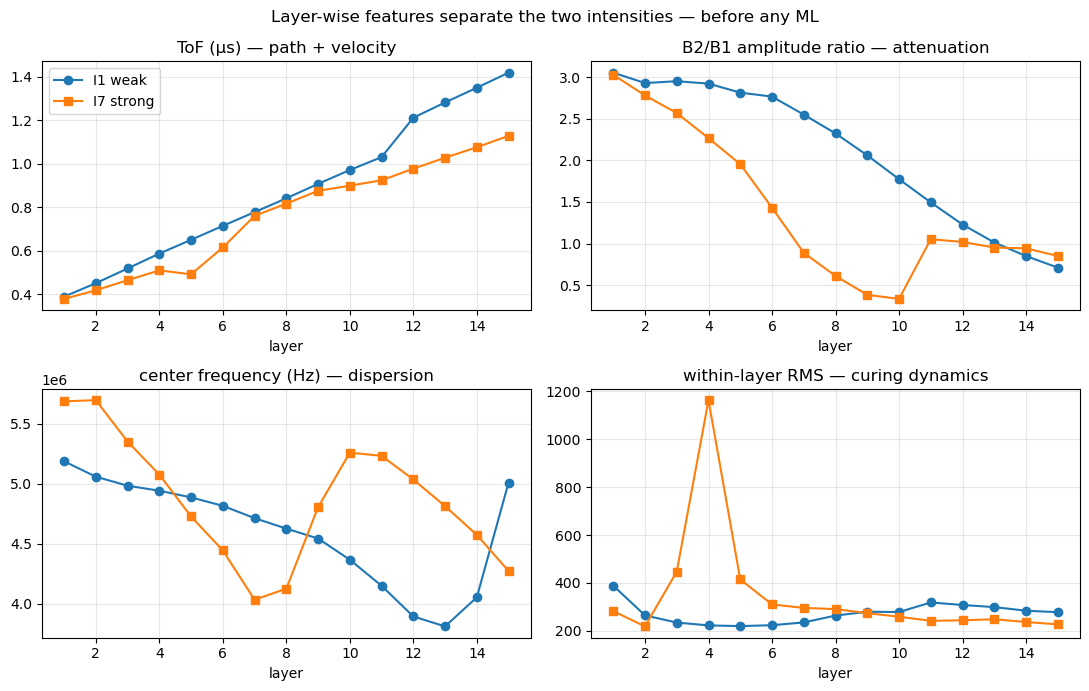

In [5]:
# Four features, one per physical mechanism (see the panel titles).
names = ["ToF", "amplitude", "Center_Freq", "frame_diff_rms"]
titles = ["ToF (µs) — path + velocity", "B2/B1 amplitude ratio — attenuation",
          "center frequency (Hz) — dispersion", "within-layer RMS — curing dynamics"]
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, n, ti in zip(axes.ravel(), names, titles):
    ax.plot(F1.index, F1[n], "o-", label="I1 weak", color="tab:blue")
    ax.plot(F7.index, F7[n], "s-", label="I7 strong", color="tab:orange")
    ax.set(title=ti, xlabel="layer"); ax.grid(alpha=0.3)
axes[0, 0].legend()
plt.suptitle("Layer-wise features separate the two intensities — before any ML")
plt.tight_layout(); plt.show()


**Read the four panels like a physicist:**

- *ToF* rises for both (path), but slower for I7 (faster waves in cured material).
- *Amplitude ratio* decays faster for I7 (stiffer network → more attenuation).
- *Center frequency* separates the materials (frequency-dependent loss).
- *Within-layer RMS* is higher for the weak cure — unstable, incomplete curing.

## 3. Sanity check against the paper's stored features

The repository ships the paper's full 50-sample feature table
(`feature11.csv`, 11 features × 30 layer slots). Compare our recomputed ToF
with the stored one for the same condition (15 layers, I1 = 10%).

---

**Input** — two things that came from completely different routes: (a)
`data/feature11.csv`, produced by the **paper's own pipeline** from the full raw
dataset — 50 rows, one per printed sample, with columns named
`Layer_{i}_{feature}` for i = 1…30 (unused slots are zero-padded); and (b) the
`F1` table we just rebuilt in this notebook from the raw `.npz`.

**What this cell does** — selects the single row of the stored table that
matches our sample (`layer == 15` **and** `intensity == 10`; the design has
exactly one print per combination, so this row is unique — `intensity` is stored
as *percent of maximum lamp power*, and 10% = I1 = 10.70 mW/cm²), pulls out its
15 stored ToF values, and overlays them on ours.

**Output** — a comparison plot and a correlation number (≈0.99). It will not be
exactly 1: the teaching tracker is a simplified re-implementation. Agreement at
this level tells us the rest of the series rests on the same physics as the
published pipeline.


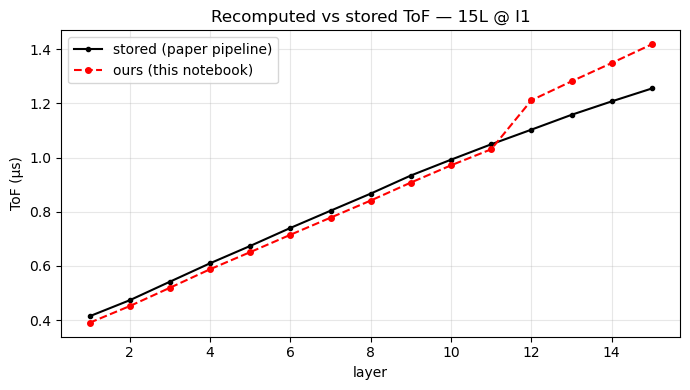

correlation: 0.9895


In [6]:
# The paper's own feature table: 50 rows (one per printed sample), wide format
# with columns Layer_1_ToF ... Layer_30_within_layer_std.
df = iu.load_features("data/feature11.csv")

# Pick the row matching OUR sample: 15 layers at 10% lamp power (= I1).
# The design grid has exactly one print per (layers, intensity) combination.
row = df[(df.layer == 15) & (df.intensity == 10)].iloc[0]
stored_tof = [row[f"Layer_{i}_ToF"] for i in range(1, 16)]   # slots 16-30 are padding

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, 16), stored_tof, "k.-", label="stored (paper pipeline)")
ax.plot(F1.index, F1.ToF, "ro--", ms=4, label="ours (this notebook)")
ax.set(xlabel="layer", ylabel="ToF (µs)", title="Recomputed vs stored ToF — 15L @ I1")
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()
corr = np.corrcoef(stored_tof, F1.ToF)[0, 1]
print(f"correlation: {corr:.4f}")


## 4. The whole design grid at a glance — feature heatmaps

Now use the full 50-sample table: layer × intensity heatmaps for one layer-count
group (the paper's Fig. 9/11 style). The structure is visible to the naked eye.

---

**Input** — the complete `feature11.csv` table (`df`), not just our three
prints. We use the **30-layer group**: 10 prints, one per intensity I1…I10, each
with 30 filled layer slots.

**What this cell does** — for a chosen feature, gathers the 10 rows into a
matrix of shape (30 layers × 10 intensities) and draws it as an image: vertical
axis = depth into the print, horizontal axis = light dose.

**Output** — three heatmaps. Read them as the whole experimental design in one
picture: ToF increases downward (the part grows), the amplitude ratio falls to
the right (more dose → more attenuation), and the within-layer RMS lights up on
the weak-cure side.


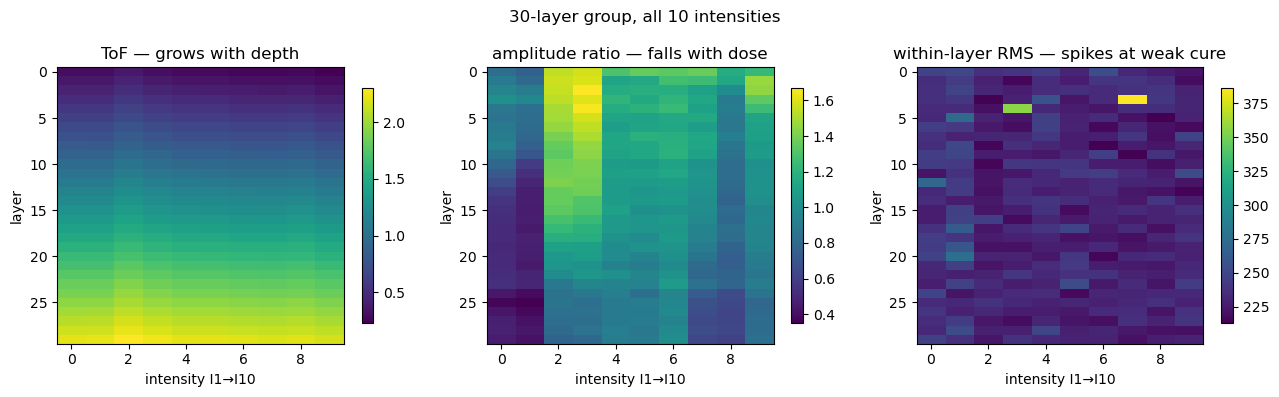

In [7]:
def heat(ax, base, group_layers, title, cmap="viridis"):
    """Draw a (layer × intensity) heatmap of one feature for one layer group."""
    g = df[df.layer == group_layers].sort_values("intensity")   # 10 prints, I1..I10
    # Build the matrix column by column (one column per print), then transpose
    # so that rows = layers (depth) and columns = intensity (dose).
    M = np.array([[r[f"Layer_{i}_{base}"] for i in range(1, group_layers + 1)]
                  for _, r in g.iterrows()]).T          # layers × intensities
    im = ax.imshow(M, aspect="auto", origin="upper", cmap=cmap)
    ax.set(xlabel="intensity I1→I10", ylabel="layer", title=title)
    return im

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, base, ti in zip(axes,
        ["ToF", "amplitude", "frame_diff_rms"],
        ["ToF — grows with depth", "amplitude ratio — falls with dose",
         "within-layer RMS — spikes at weak cure"]):
    im = heat(ax, base, 30, ti)
    plt.colorbar(im, ax=ax, shrink=0.85)
plt.suptitle("30-layer group, all 10 intensities")
plt.tight_layout(); plt.show()


## Exercises

1. Recreate the heatmaps for the 10-layer group. Where is within-layer RMS
   largest, and why does that match the physics of incomplete curing?
2. `iu.layer_features` uses the **last** frame of each layer for the
   across-layer features. Re-run section 2 using the *reference* frame
   (index 0) instead. Which features change most, and why?
3. Design ONE new feature you believe tracks curing but not geometry. Compute
   it for I1 vs I7 and defend your design in two sentences. *(You will test it
   properly — leak-free — after Notebook 3.)*

**Next notebook:** we assemble the 344-dimensional representation and learn —
without fooling ourselves.
